In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from sklearn.cluster import KMeans
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score

In [44]:
df = pd.read_csv('/content/Movie and Emotional Attachment Survey.csv')
STORY_COLS = [
    'The storytelling in this movie was emotionally powerful.',
    'The story made me feel strong emotions.',
    'The emotional moments felt genuine and realistic.',
    "The characters' emotional experiences were clearly expressed.",
    "The story focused strongly on characters' feelings and relationships."
]
ATTACH_COLS = [
    'I feel attached to the characters in this movie.',
    'I still think about this movie or its characters after watching it.',
    'I would like to watch this movie again in the future.',
    'I would recommend this movie to others.',
    'This movie has a special place in my memory compared to other movies.'
]
ALL_LIKERT = STORY_COLS + ATTACH_COLS

print("=" * 65)
print("MOVIE vs EMOTIONAL ATTACHMENT SURVEY  |  WORKSHOP 2")
print("=" * 65)
print(f"\nDataset shape  : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print("\nColumn list:")
for c in df.columns:
    print(f"  {c}")
print("\nBasic statistics (numeric):")
print(df.describe().round(2).to_string())

COLORS = ['#1565C0', '#E53935', '#43A047', '#8E24AA',
          '#FB8C00', '#00ACC1', '#6D4C41', '#3949AB']
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

MOVIE vs EMOTIONAL ATTACHMENT SURVEY  |  WORKSHOP 2

Dataset shape  : (5000, 18)
Missing values : 0

Column list:
  Age
  Gender
  Watched emotional movie in last 12 months
  Movie/Book that affected you most recently
  How many times watched
  When watched most recently
  The storytelling in this movie was emotionally powerful.
  The story made me feel strong emotions.
  The emotional moments felt genuine and realistic.
  The characters' emotional experiences were clearly expressed.
  The story focused strongly on characters' feelings and relationships.
  I feel attached to the characters in this movie.
  I still think about this movie or its characters after watching it.
  I would like to watch this movie again in the future.
  I would recommend this movie to others.
  This movie has a special place in my memory compared to other movies.
  Emotional Storytelling Score
  Audience Attachment Score

Basic statistics (numeric):
       The storytelling in this movie was emotionally powerf

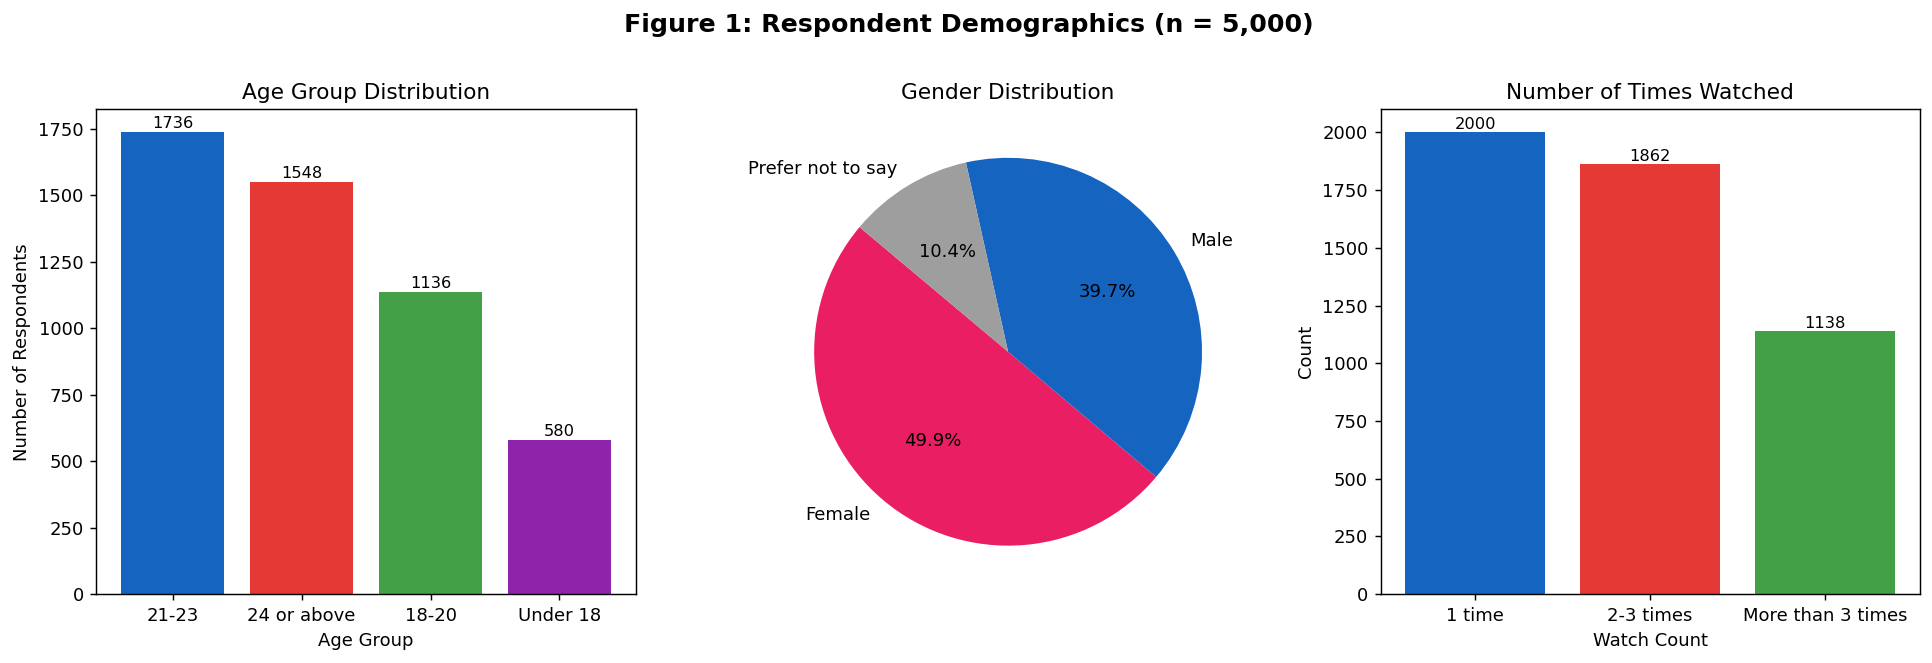

In [30]:
# ─────────────────────────────────────────────────────────────
# FIG 1 – DEMOGRAPHIC OVERVIEW
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1: Respondent Demographics (n = 5,000)', fontsize=14, fontweight='bold', y=1.01)

age_order = ['Under 18', '18-20', '21-23', '24 or above']
# normalise hyphens
df['Age_clean'] = df['Age'].str.replace('\u2013', '-').str.replace('\u2014', '-')
age_map = {'Under 18': 'Under 18', '18\u201320': '18-20', '21\u201323': '21-23', '24 or above': '24 or above'}
df['Age_clean'] = df['Age'].map(lambda x: x.replace('\u2013', '-'))
age_vals = df['Age_clean'].value_counts()

axes[0].bar(age_vals.index, age_vals.values, color=COLORS[:len(age_vals)])
axes[0].set_title('Age Group Distribution')
axes[0].set_ylabel('Number of Respondents')
axes[0].set_xlabel('Age Group')
for i, (k, v) in enumerate(age_vals.items()):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=9)

gender_vals = df['Gender'].value_counts()
axes[1].pie(gender_vals.values, labels=gender_vals.index, autopct='%1.1f%%',
            colors=['#E91E63', '#1565C0', '#9E9E9E'], startangle=140)
axes[1].set_title('Gender Distribution')

watch_order = ['1 time', '2-3 times', 'More than 3 times']
df['Watch_clean'] = df['How many times watched'].str.replace('\u2013', '-')
watch_vals = df['Watch_clean'].value_counts()
axes[2].bar(watch_vals.index, watch_vals.values, color=COLORS[:len(watch_vals)])
axes[2].set_title('Number of Times Watched')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Watch Count')
for i, (k, v) in enumerate(watch_vals.items()):
    axes[2].text(i, v + 15, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

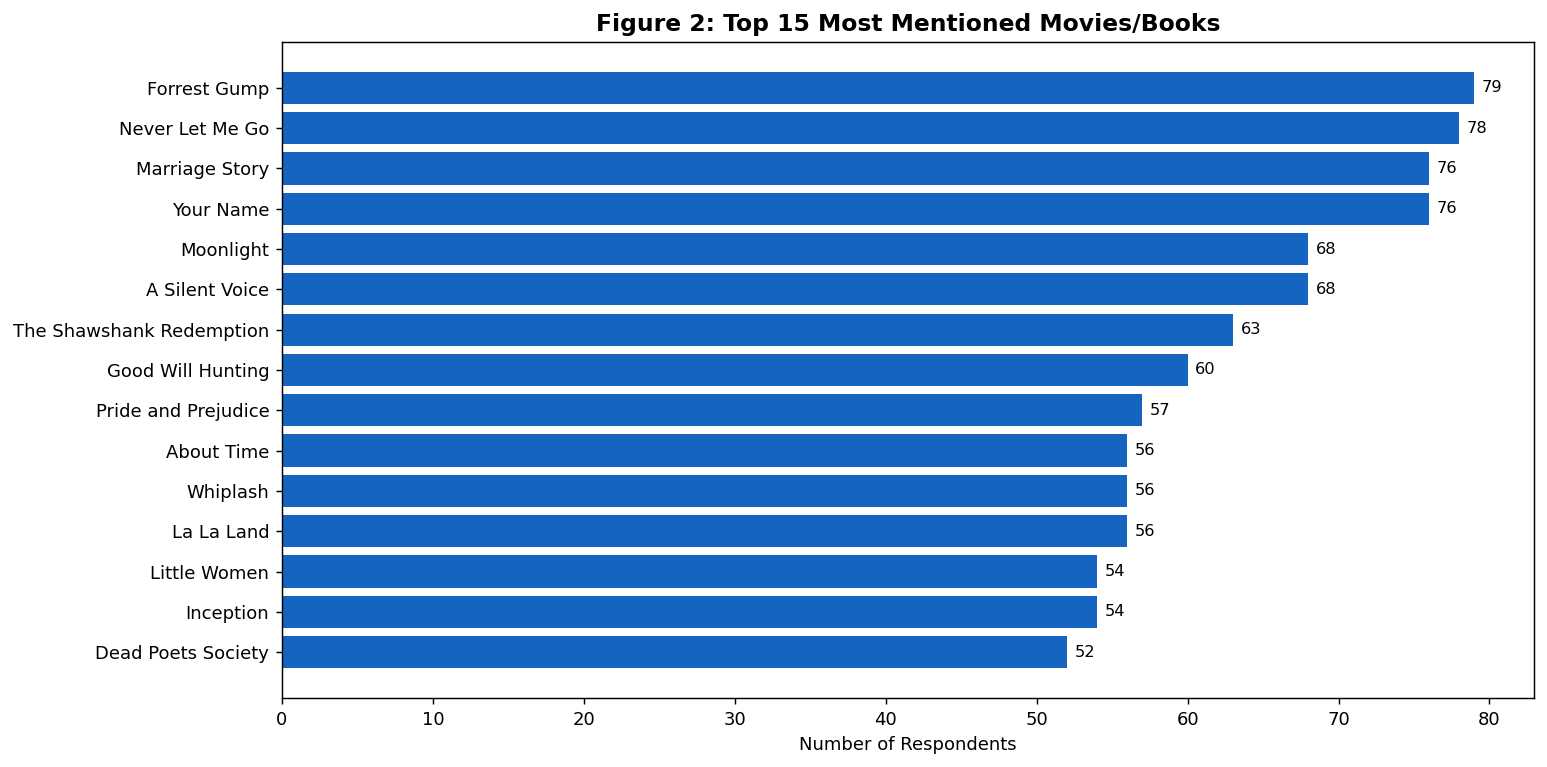

[Saved] fig2_top_movies.png


In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
top_movies = df['Movie/Book that affected you most recently'].value_counts().head(15)
bars = ax.barh(top_movies.index[::-1], top_movies.values[::-1], color=COLORS[0])
ax.set_title('Figure 2: Top 15 Most Mentioned Movies/Books', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Respondents')
for bar, val in zip(bars, top_movies.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()
print("[Saved] fig2_top_movies.png")

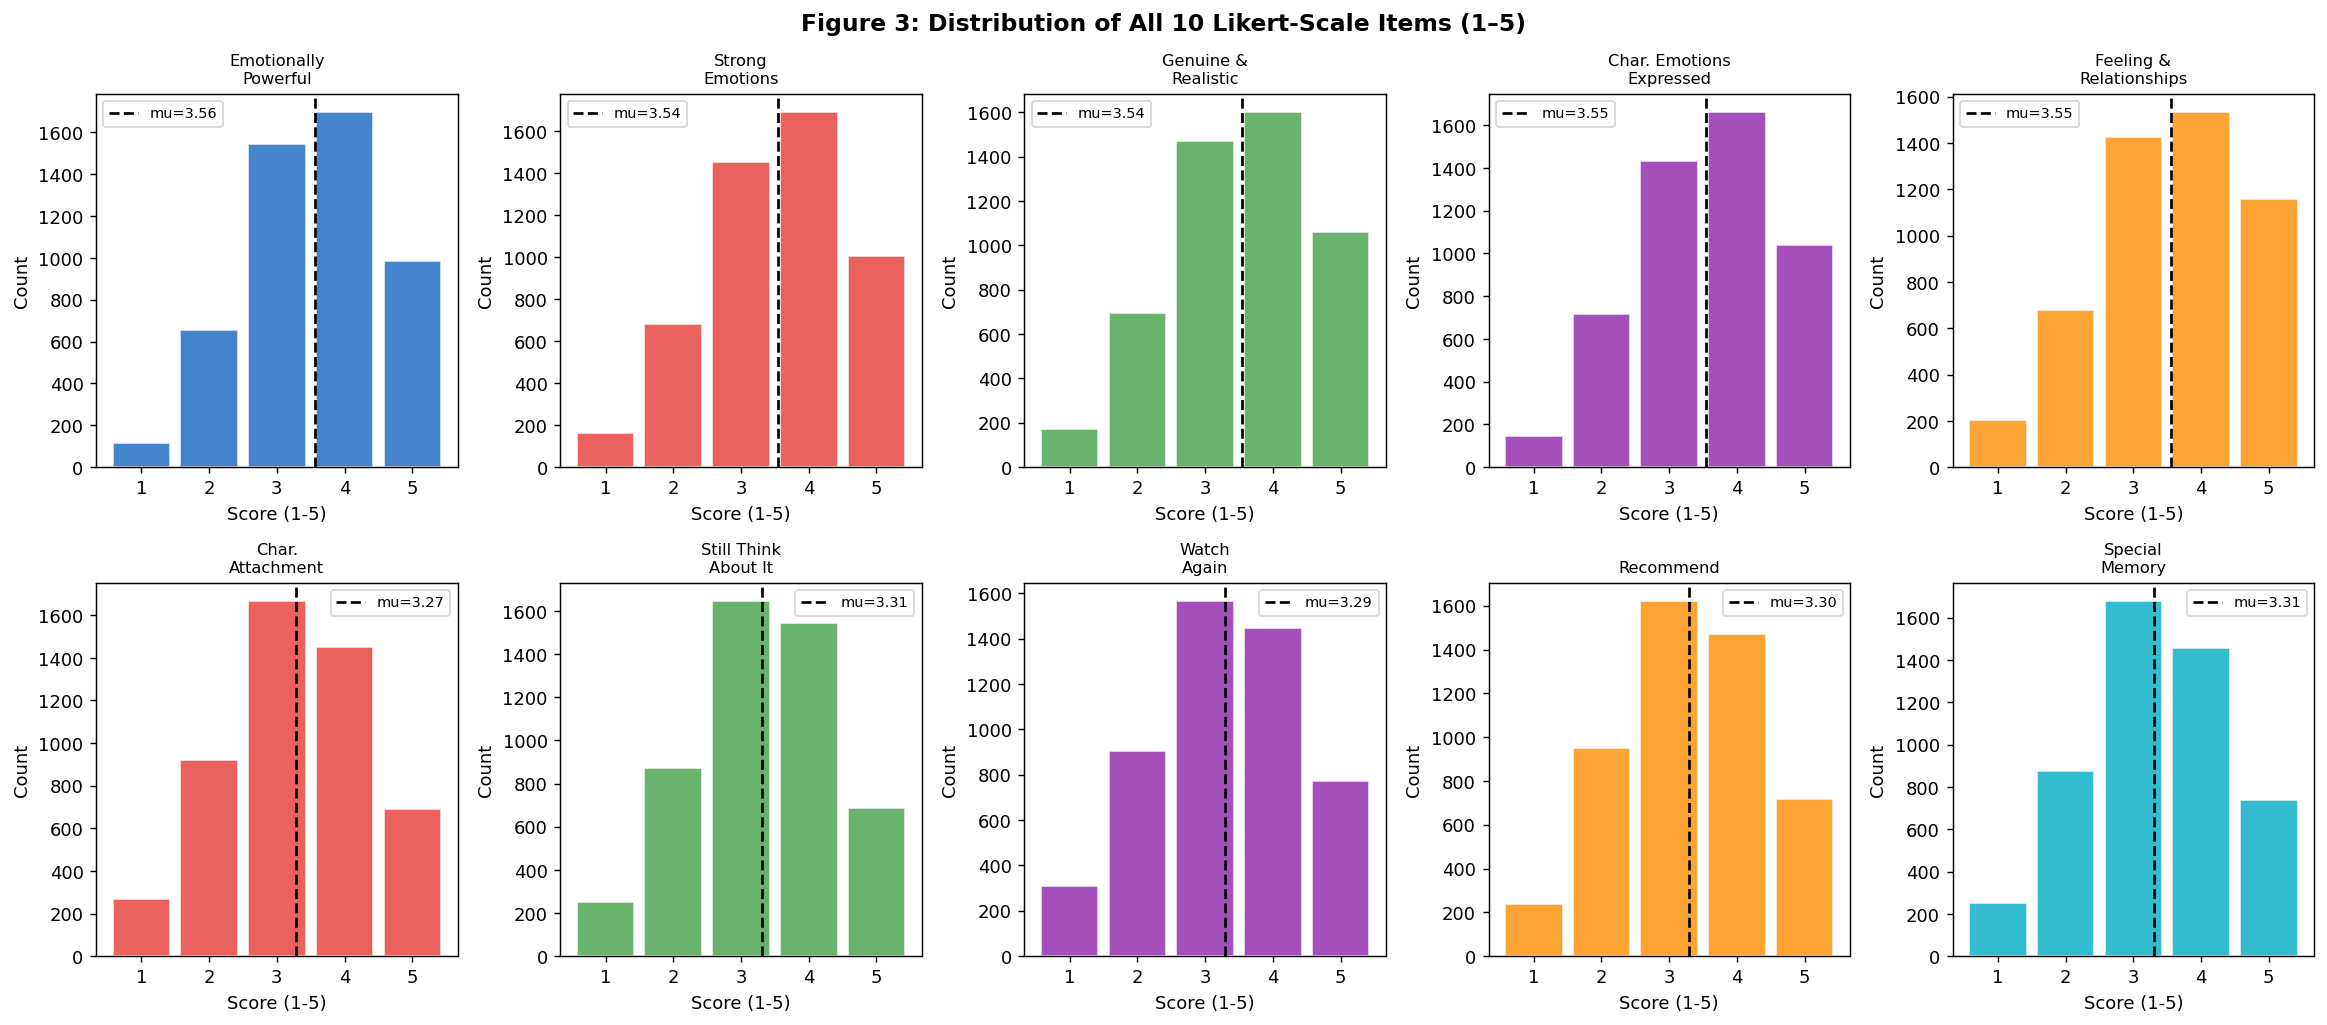

In [32]:
short_labels = [
    'Emotionally\nPowerful', 'Strong\nEmotions', 'Genuine &\nRealistic',
    'Char. Emotions\nExpressed', 'Feeling &\nRelationships',
    'Char.\nAttachment', 'Still Think\nAbout It', 'Watch\nAgain',
    'Recommend', 'Special\nMemory'
]
color_map = COLORS[:5] + ['#E53935', '#43A047', '#8E24AA', '#FB8C00', '#00ACC1']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Figure 3: Distribution of All 10 Likert-Scale Items (1–5)', fontsize=13, fontweight='bold')
for ax, col, label, clr in zip(axes.flat, ALL_LIKERT, short_labels, color_map):
    ax.hist(df[col], bins=[0.5,1.5,2.5,3.5,4.5,5.5], color=clr, alpha=0.8, edgecolor='white', rwidth=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mu={df[col].mean():.2f}')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Count')
    ax.set_xticks([1,2,3,4,5])
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

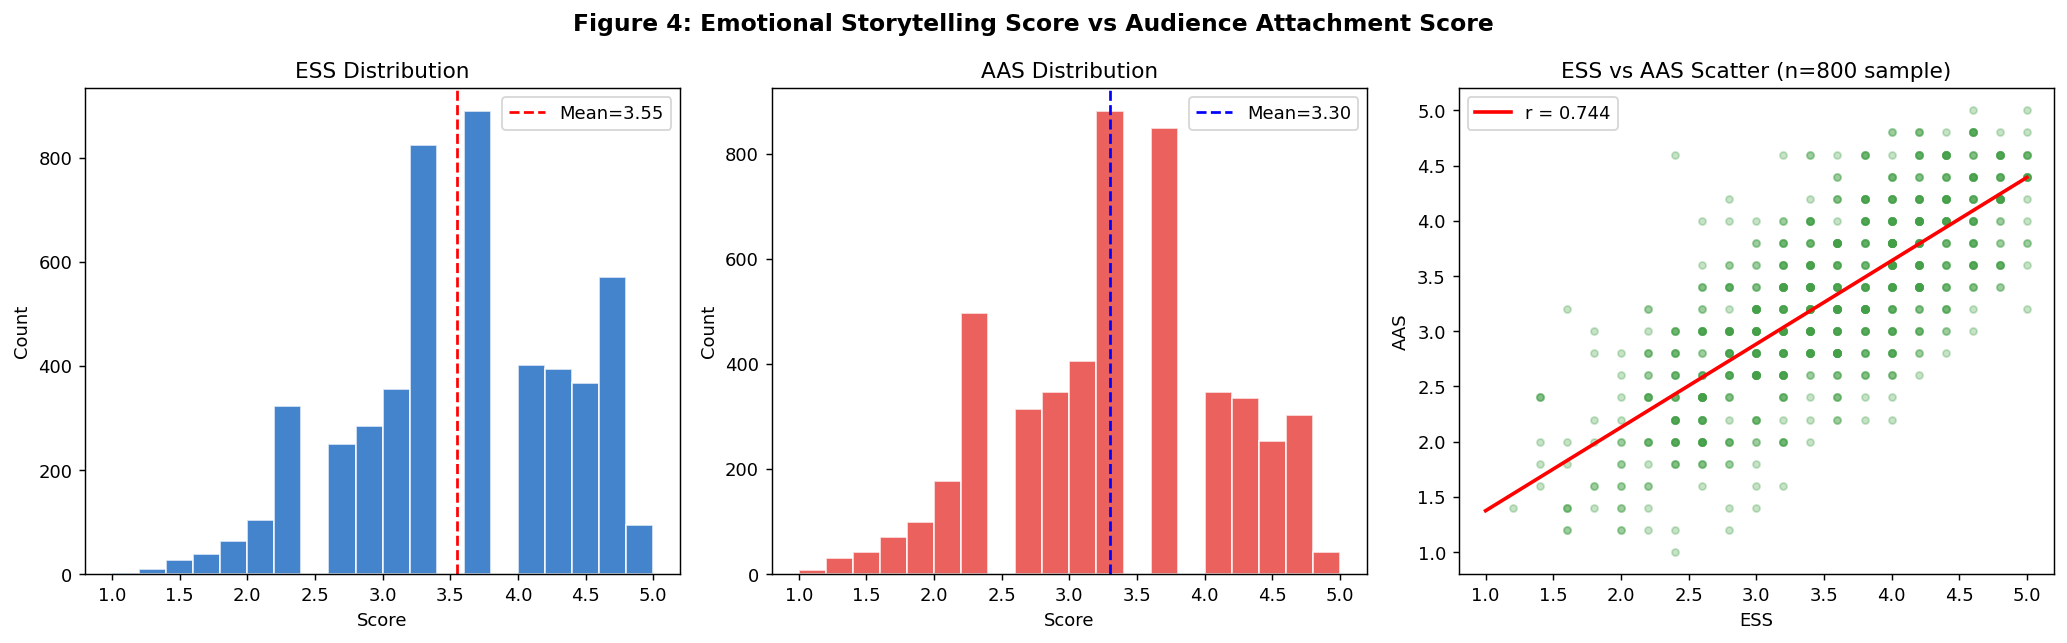

In [33]:
# ─────────────────────────────────────────────────────────────
# FIG 4 – ESS vs AAS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 4: Emotional Storytelling Score vs Audience Attachment Score',
             fontsize=13, fontweight='bold')

axes[0].hist(df['Emotional Storytelling Score'], bins=20, color=COLORS[0], alpha=0.8, edgecolor='white')
axes[0].axvline(df['Emotional Storytelling Score'].mean(), color='red', linestyle='--',
                label=f"Mean={df['Emotional Storytelling Score'].mean():.2f}")
axes[0].set_title('ESS Distribution'); axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Audience Attachment Score'], bins=20, color=COLORS[1], alpha=0.8, edgecolor='white')
axes[1].axvline(df['Audience Attachment Score'].mean(), color='blue', linestyle='--',
                label=f"Mean={df['Audience Attachment Score'].mean():.2f}")
axes[1].set_title('AAS Distribution'); axes[1].set_xlabel('Score'); axes[1].set_ylabel('Count')
axes[1].legend()

sample = df.sample(800, random_state=42)
axes[2].scatter(sample['Emotional Storytelling Score'], sample['Audience Attachment Score'],
                alpha=0.3, color=COLORS[2], s=15)
m, b = np.polyfit(df['Emotional Storytelling Score'], df['Audience Attachment Score'], 1)
x_line = np.linspace(df['Emotional Storytelling Score'].min(), df['Emotional Storytelling Score'].max(), 100)
axes[2].plot(x_line, m * x_line + b, color='red', linewidth=2, label='r = 0.744')
axes[2].set_xlabel('ESS'); axes[2].set_ylabel('AAS')
axes[2].set_title('ESS vs AAS Scatter (n=800 sample)'); axes[2].legend()

plt.tight_layout()
plt.show()

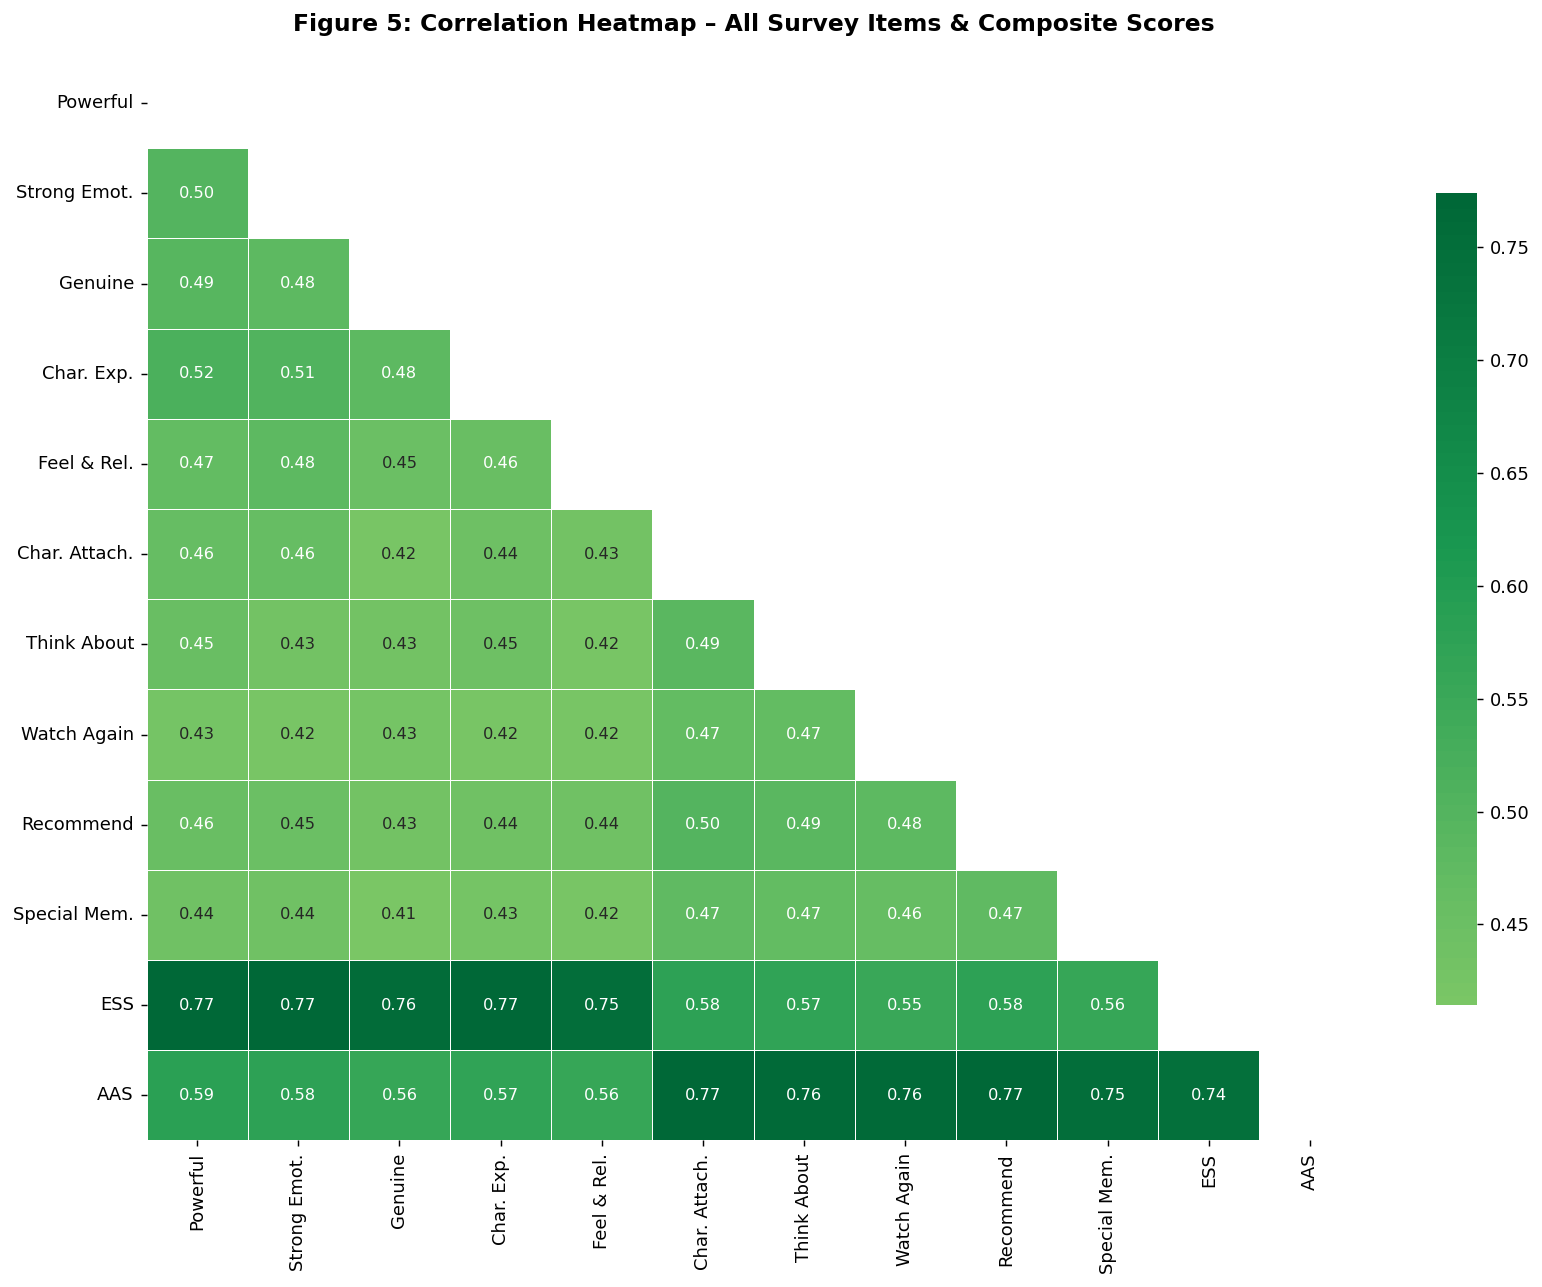

In [34]:
# ─────────────────────────────────────────────────────────────
# FIG 5 – CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────
num_cols = ALL_LIKERT + ['Emotional Storytelling Score', 'Audience Attachment Score']
corr = df[num_cols].corr()
short_heat = ['Powerful', 'Strong Emot.', 'Genuine', 'Char. Exp.',
              'Feel & Rel.', 'Char. Attach.', 'Think About',
              'Watch Again', 'Recommend', 'Special Mem.', 'ESS', 'AAS']
corr.index = short_heat; corr.columns = short_heat

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.75},
            annot_kws={'size': 9})
ax.set_title('Figure 5: Correlation Heatmap – All Survey Items & Composite Scores',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

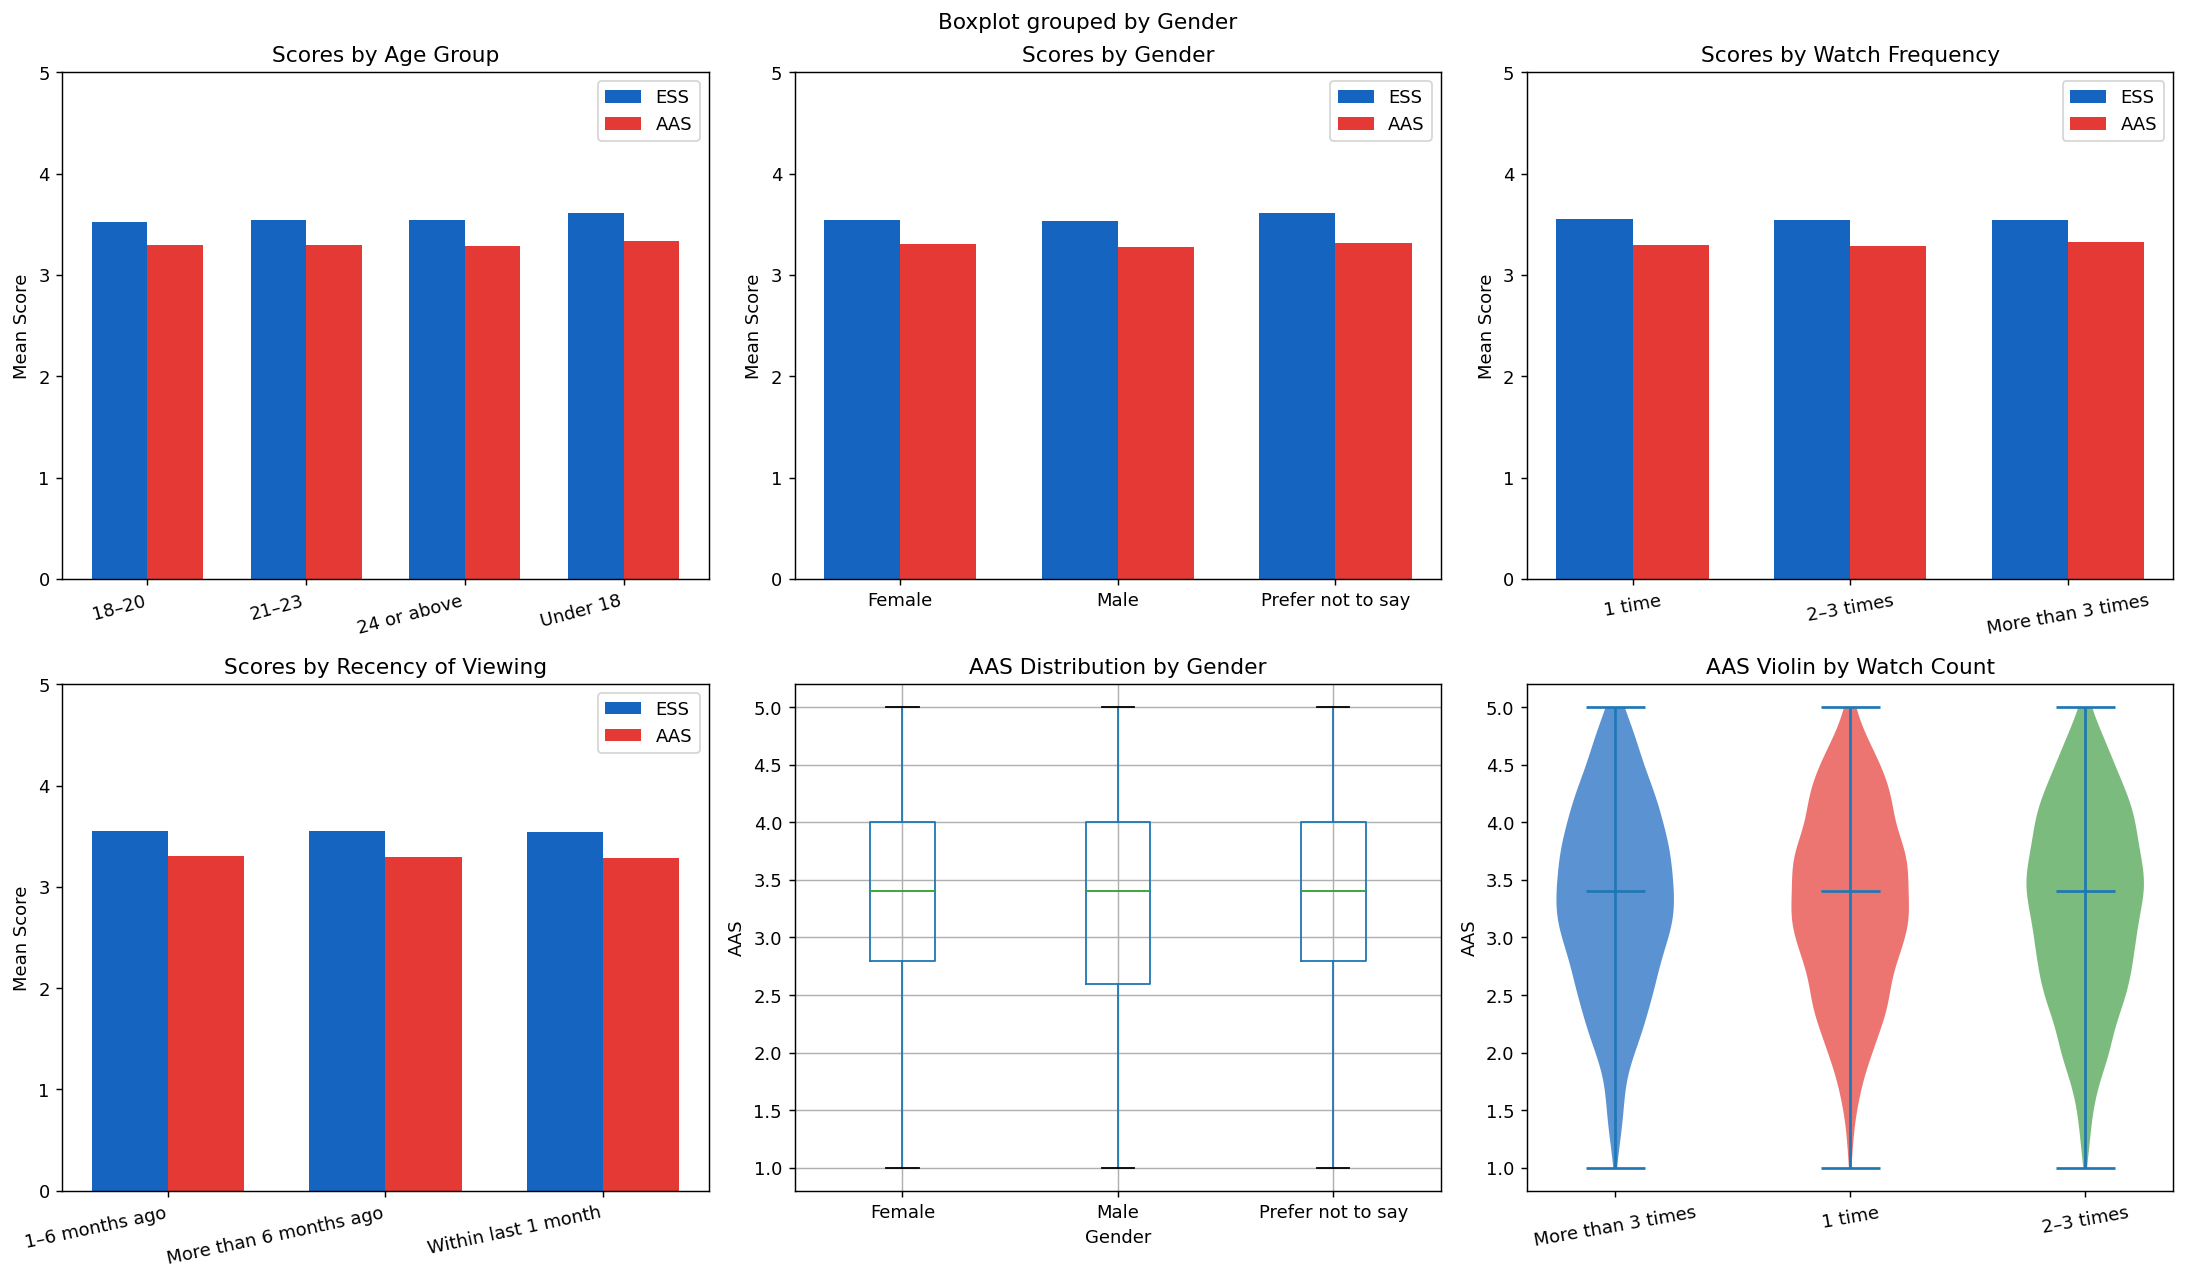

In [35]:
# ─────────────────────────────────────────────────────────────
# FIG 6 – SCORES BY DEMOGRAPHICS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Figure 6: ESS & AAS Across Demographics and Viewing Behaviour',
             fontsize=13, fontweight='bold')
w = 0.35

# Age
ess_age = df.groupby('Age')['Emotional Storytelling Score'].mean()
aas_age = df.groupby('Age')['Audience Attachment Score'].mean()
xa = np.arange(len(ess_age))
axes[0,0].bar(xa - w/2, ess_age.values, w, label='ESS', color=COLORS[0])
axes[0,0].bar(xa + w/2, aas_age.values, w, label='AAS', color=COLORS[1])
axes[0,0].set_xticks(xa); axes[0,0].set_xticklabels(ess_age.index, rotation=15, ha='right')
axes[0,0].set_title('Scores by Age Group'); axes[0,0].set_ylabel('Mean Score')
axes[0,0].legend(); axes[0,0].set_ylim(0, 5)

# Gender
ess_g = df.groupby('Gender')['Emotional Storytelling Score'].mean()
aas_g = df.groupby('Gender')['Audience Attachment Score'].mean()
xg = np.arange(len(ess_g))
axes[0,1].bar(xg - w/2, ess_g.values, w, label='ESS', color=COLORS[0])
axes[0,1].bar(xg + w/2, aas_g.values, w, label='AAS', color=COLORS[1])
axes[0,1].set_xticks(xg); axes[0,1].set_xticklabels(ess_g.index)
axes[0,1].set_title('Scores by Gender'); axes[0,1].set_ylabel('Mean Score')
axes[0,1].legend(); axes[0,1].set_ylim(0, 5)

# Watch frequency
ess_w = df.groupby('How many times watched')['Emotional Storytelling Score'].mean()
aas_w = df.groupby('How many times watched')['Audience Attachment Score'].mean()
xw = np.arange(len(ess_w))
axes[0,2].bar(xw - w/2, ess_w.values, w, label='ESS', color=COLORS[0])
axes[0,2].bar(xw + w/2, aas_w.values, w, label='AAS', color=COLORS[1])
axes[0,2].set_xticks(xw); axes[0,2].set_xticklabels(ess_w.index, rotation=10)
axes[0,2].set_title('Scores by Watch Frequency'); axes[0,2].set_ylabel('Mean Score')
axes[0,2].legend(); axes[0,2].set_ylim(0, 5)

# Recency
ess_r = df.groupby('When watched most recently')['Emotional Storytelling Score'].mean()
aas_r = df.groupby('When watched most recently')['Audience Attachment Score'].mean()
xr = np.arange(len(ess_r))
axes[1,0].bar(xr - w/2, ess_r.values, w, label='ESS', color=COLORS[0])
axes[1,0].bar(xr + w/2, aas_r.values, w, label='AAS', color=COLORS[1])
axes[1,0].set_xticks(xr); axes[1,0].set_xticklabels(ess_r.index, rotation=12, ha='right')
axes[1,0].set_title('Scores by Recency of Viewing'); axes[1,0].set_ylabel('Mean Score')
axes[1,0].legend(); axes[1,0].set_ylim(0, 5)

# AAS boxplot by gender
df.boxplot(column='Audience Attachment Score', by='Gender', ax=axes[1,1])
axes[1,1].set_title('AAS Distribution by Gender')
axes[1,1].set_xlabel('Gender'); axes[1,1].set_ylabel('AAS')
plt.sca(axes[1,1]); plt.title('AAS Distribution by Gender')

# AAS violin by watch count
watch_groups = [df[df['How many times watched'] == w2]['Audience Attachment Score'].values
                for w2 in df['How many times watched'].unique()]
labels_v = list(df['How many times watched'].unique())
vp = axes[1,2].violinplot(watch_groups, positions=range(len(labels_v)), showmedians=True)
for pc, col in zip(vp['bodies'], COLORS[:len(labels_v)]):
    pc.set_facecolor(col); pc.set_alpha(0.7)
axes[1,2].set_xticks(range(len(labels_v)))
axes[1,2].set_xticklabels(labels_v, rotation=10)
axes[1,2].set_title('AAS Violin by Watch Count'); axes[1,2].set_ylabel('AAS')

plt.tight_layout()
plt.show()


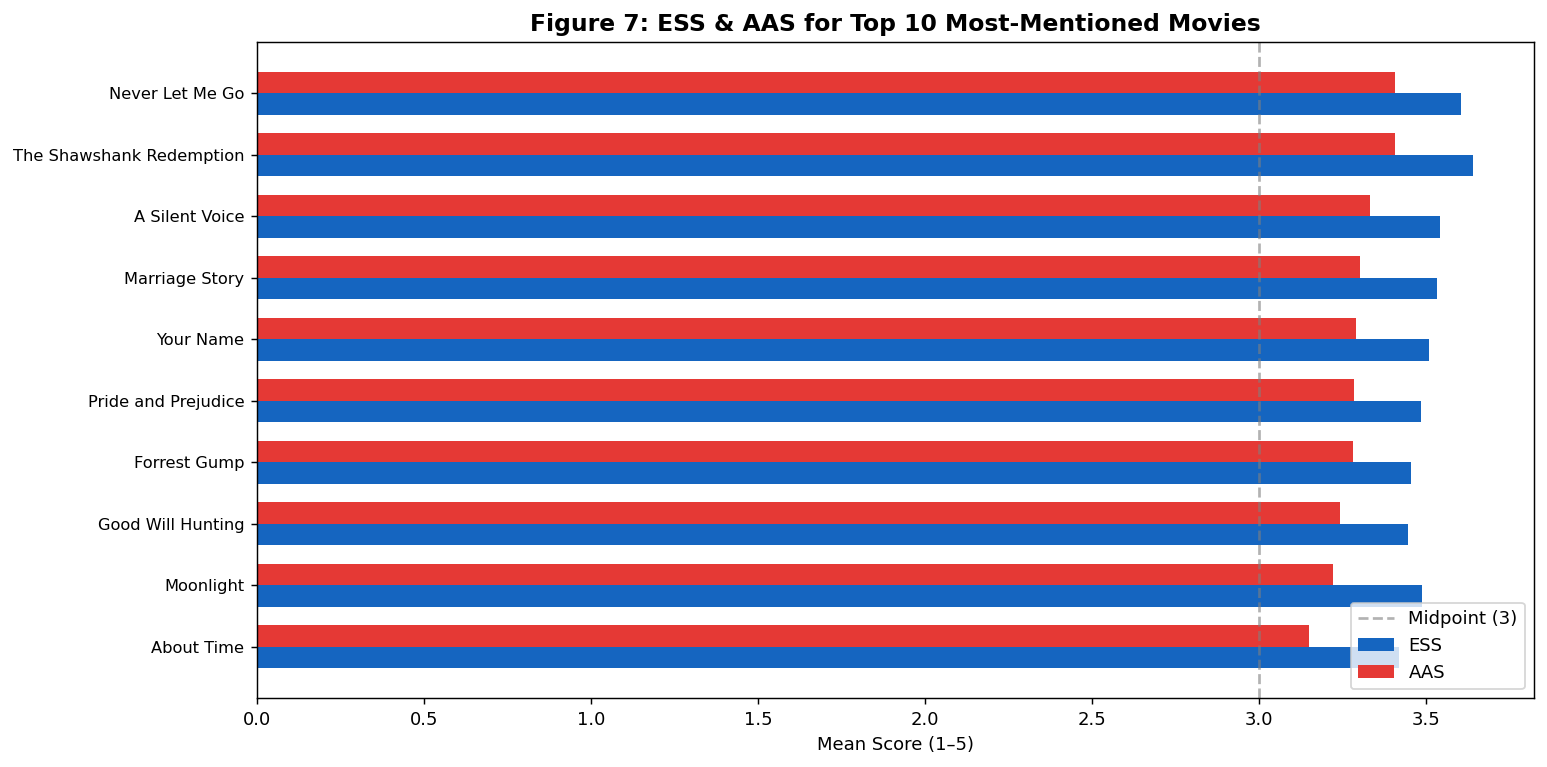

In [36]:
# ─────────────────────────────────────────────────────────────
# FIG 7 – TOP 10 MOVIES: ESS & AAS
# ─────────────────────────────────────────────────────────────
top10_names = df['Movie/Book that affected you most recently'].value_counts().head(10).index
top10_df = df[df['Movie/Book that affected you most recently'].isin(top10_names)]
movie_scores = top10_df.groupby('Movie/Book that affected you most recently')[
    ['Emotional Storytelling Score', 'Audience Attachment Score']].mean().sort_values('Audience Attachment Score')

fig, ax = plt.subplots(figsize=(12, 6))
xm = np.arange(len(movie_scores)); wm = 0.35
ax.barh(xm - wm/2, movie_scores['Emotional Storytelling Score'], wm, label='ESS', color=COLORS[0])
ax.barh(xm + wm/2, movie_scores['Audience Attachment Score'], wm, label='AAS', color=COLORS[1])
ax.set_yticks(xm); ax.set_yticklabels(movie_scores.index, fontsize=9)
ax.set_xlabel('Mean Score (1–5)')
ax.set_title('Figure 7: ESS & AAS for Top 10 Most-Mentioned Movies', fontsize=13, fontweight='bold')
ax.axvline(3, color='gray', linestyle='--', alpha=0.6, label='Midpoint (3)')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────
# DATA TRANSFORMATION
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("DATA TRANSFORMATION")
print("=" * 65)

df_enc = df.copy()
le = LabelEncoder()
cat_cols = ['Age', 'Gender', 'How many times watched', 'When watched most recently']
for col in cat_cols:
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col])
    print(f"  Encoded '{col}'")

df_enc['high_attachment'] = (df_enc['Audience Attachment Score'] >= 3.5).astype(int)
print(f"\nTarget: high_attachment (AAS >= 3.5)")
print(df_enc['high_attachment'].value_counts())
print(f"High attachment rate: {df_enc['high_attachment'].mean():.1%}")


DATA TRANSFORMATION
  Encoded 'Age'
  Encoded 'Gender'
  Encoded 'How many times watched'
  Encoded 'When watched most recently'

Target: high_attachment (AAS >= 3.5)
high_attachment
0    2869
1    2131
Name: count, dtype: int64
High attachment rate: 42.6%


In [38]:
# ─────────────────────────────────────────────────────────────
# MODEL TRAINING
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL TRAINING")
print("=" * 65)

features = STORY_COLS + ['Age_enc', 'Gender_enc',
                          'How many times watched_enc',
                          'When watched most recently_enc']
X = df_enc[features]
y = df_enc['high_attachment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    Xtr = X_tr_s if name == 'Logistic Regression' else X_train.values
    Xte = X_te_s if name == 'Logistic Regression' else X_test.values
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {'accuracy': acc, 'auc': auc, 'cv_acc': cv,
                     'model': model, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"\n{name}: Accuracy={acc:.4f}  AUC={auc:.4f}  CV_Acc={cv:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Low','High']))

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest model: {best_name}  (AUC={results[best_name]['auc']:.4f})")



MODEL TRAINING

Logistic Regression: Accuracy=0.7710  AUC=0.8555  CV_Acc=0.7777
              precision    recall  f1-score   support

         Low       0.80      0.81      0.80       574
        High       0.74      0.72      0.73       426

    accuracy                           0.77      1000
   macro avg       0.77      0.76      0.77      1000
weighted avg       0.77      0.77      0.77      1000


Random Forest: Accuracy=0.7320  AUC=0.8117  CV_Acc=0.7445
              precision    recall  f1-score   support

         Low       0.76      0.77      0.77       574
        High       0.69      0.68      0.68       426

    accuracy                           0.73      1000
   macro avg       0.73      0.72      0.73      1000
weighted avg       0.73      0.73      0.73      1000


Gradient Boosting: Accuracy=0.7570  AUC=0.8446  CV_Acc=0.7620
              precision    recall  f1-score   support

         Low       0.78      0.79      0.79       574
        High       0.72      0.71 

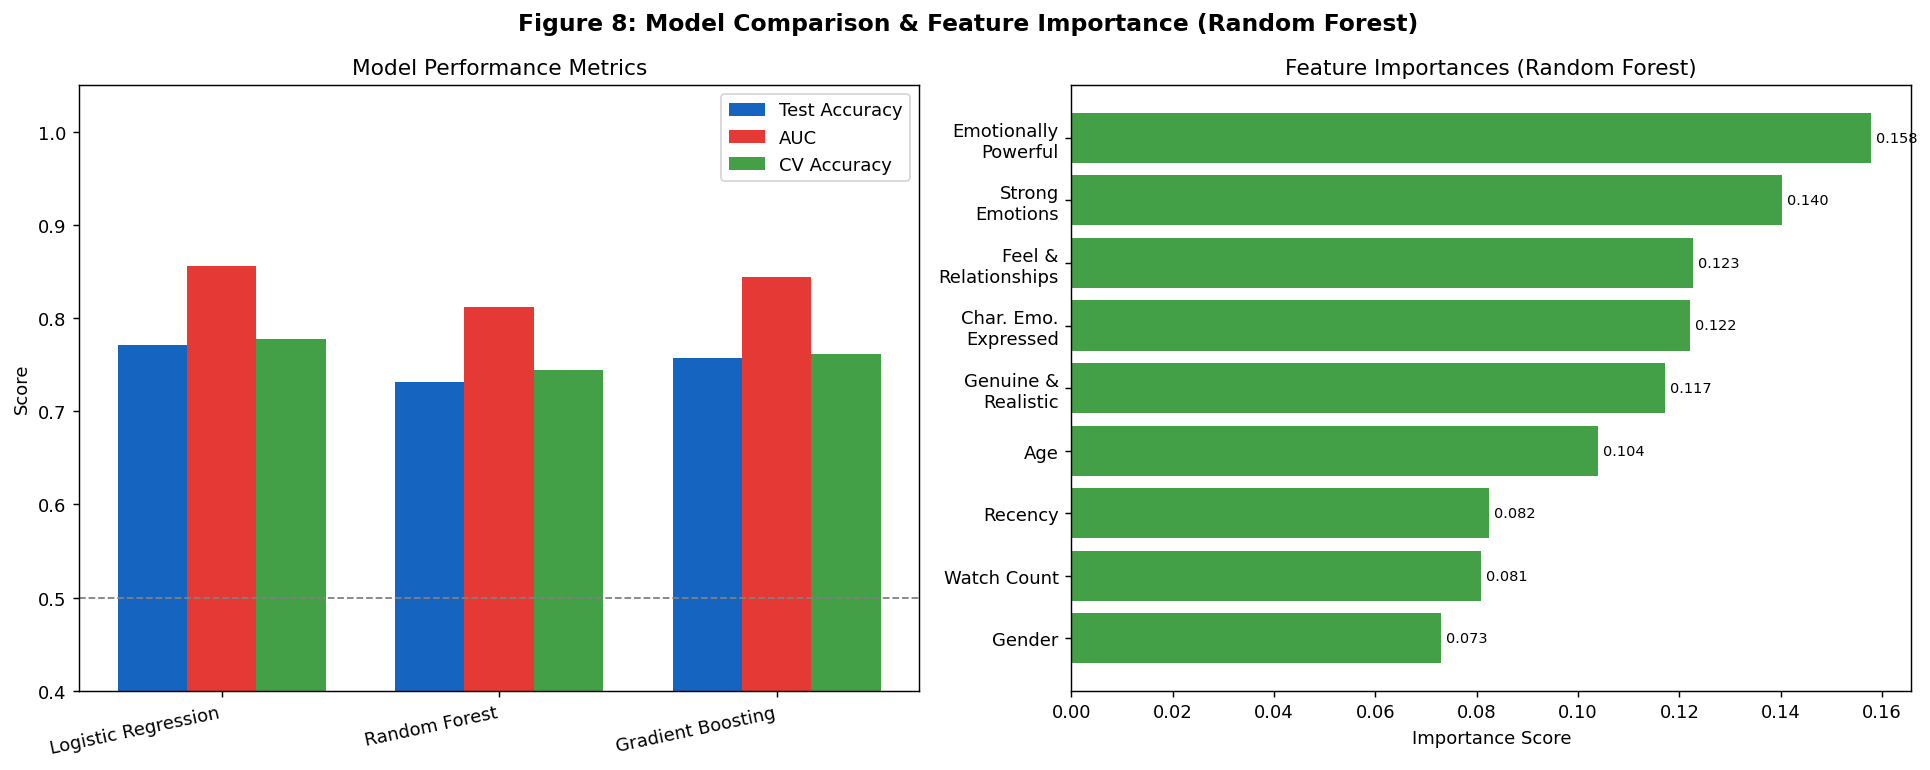

In [40]:
# ─────────────────────────────────────────────────────────────
# FIG 8 – MODEL PERFORMANCE + FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 8: Model Comparison & Feature Importance (Random Forest)',
             fontsize=13, fontweight='bold')

names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
aucs = [results[n]['auc']      for n in names]
cvs  = [results[n]['cv_acc']   for n in names]
x = np.arange(len(names)); bw = 0.25
axes[0].bar(x - bw,   accs, bw, label='Test Accuracy', color=COLORS[0])
axes[0].bar(x,        aucs, bw, label='AUC',           color=COLORS[1])
axes[0].bar(x + bw,   cvs,  bw, label='CV Accuracy',   color=COLORS[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=12, ha='right')
axes[0].set_ylim(0.4, 1.05)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Model Performance Metrics'); axes[0].set_ylabel('Score'); axes[0].legend()

short_feat = ['Emotionally\nPowerful', 'Strong\nEmotions', 'Genuine &\nRealistic',
              'Char. Emo.\nExpressed', 'Feel &\nRelationships',
              'Age', 'Gender', 'Watch Count', 'Recency']
rf_fi = pd.Series(results['Random Forest']['model'].feature_importances_,
                  index=short_feat).sort_values(ascending=True)
axes[1].barh(rf_fi.index, rf_fi.values, color=COLORS[2])
axes[1].set_title('Feature Importances (Random Forest)')
axes[1].set_xlabel('Importance Score')
for i, val in enumerate(rf_fi.values):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

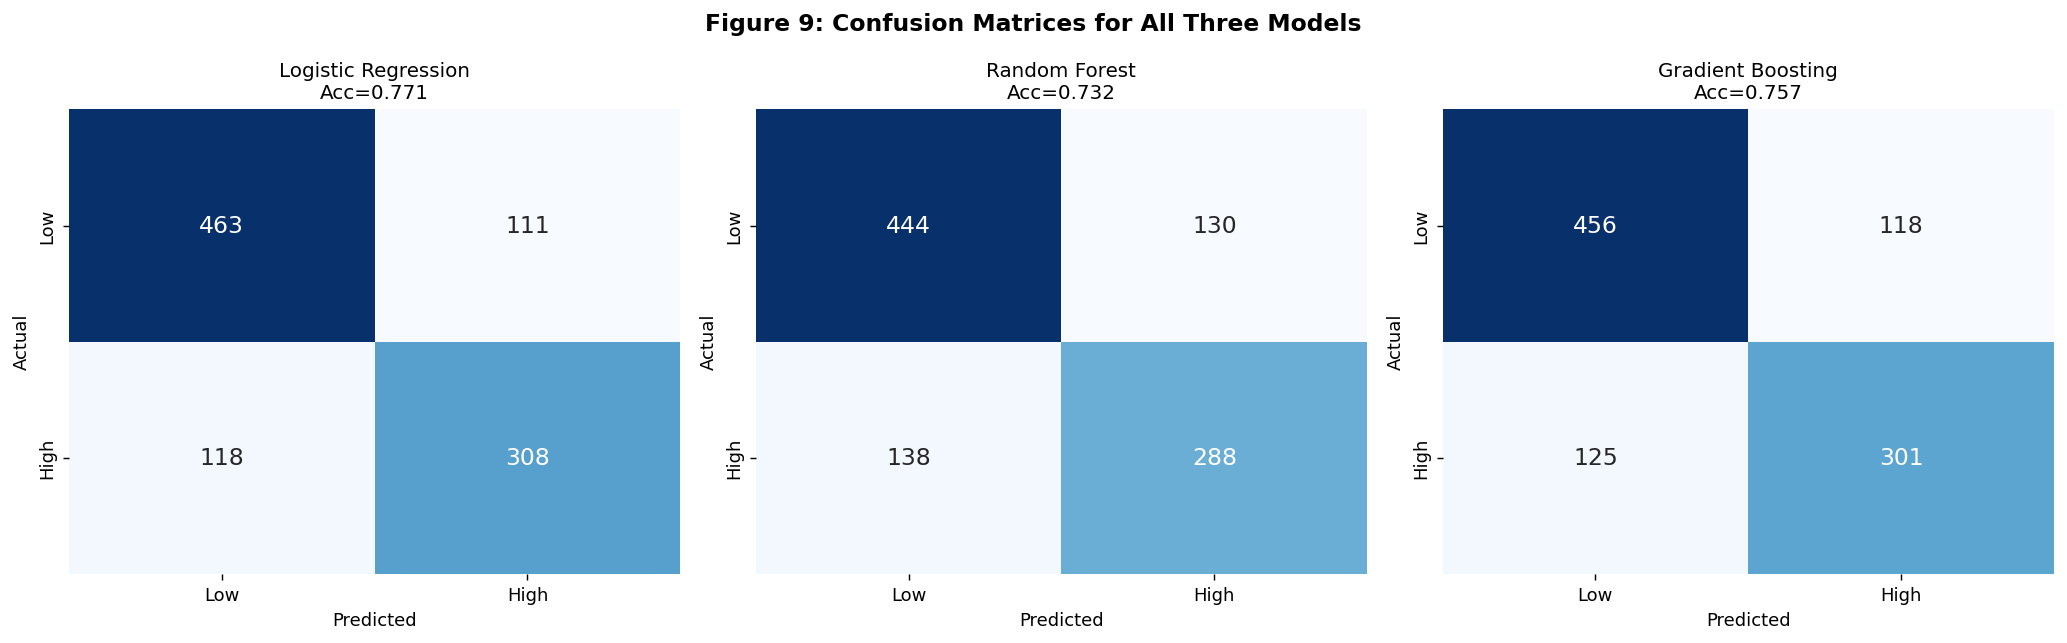

In [41]:

# FIG 9 – CONFUSION MATRICES
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 9: Confusion Matrices for All Three Models', fontsize=13, fontweight='bold')
for ax, name in zip(axes, names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low','High'], yticklabels=['Low','High'],
                cbar=False, annot_kws={'size': 13})
    ax.set_title(f'{name}\nAcc={results[name]["accuracy"]:.3f}', fontsize=11)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

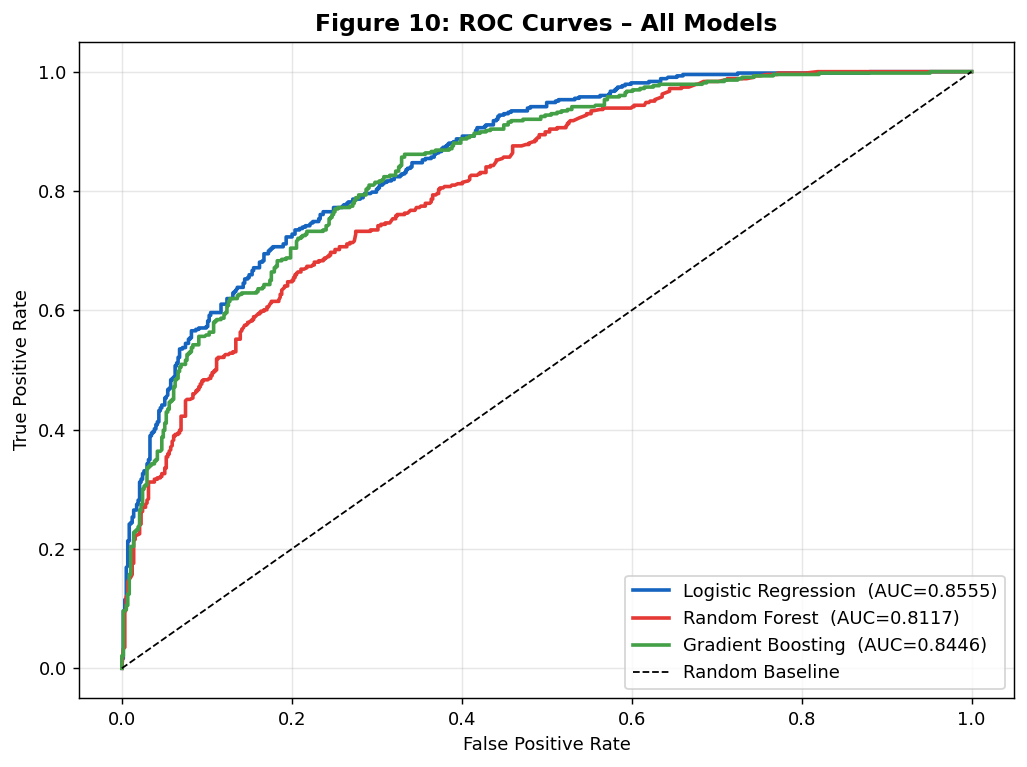

In [42]:
# ─────────────────────────────────────────────────────────────
# FIG 10 – ROC CURVES
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, color in zip(names, COLORS[:3]):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax.plot(fpr, tpr, label=f'{name}  (AUC={results[name]["auc"]:.4f})', color=color, linewidth=2)
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 10: ROC Curves – All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.tight_layout()
plt.show()

In [25]:
# ─────────────────────────────────────────────────────────────
# K-MEANS CLUSTERING
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("K-MEANS VIEWER CLUSTERING")
print("=" * 65)

clust_features = ['Emotional Storytelling Score', 'Audience Attachment Score',
                  'How many times watched_enc', 'When watched most recently_enc']
X_clust = StandardScaler().fit_transform(df_enc[clust_features])
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_clust).inertia_
           for k in range(2, 10)]

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_enc['cluster'] = kmeans.fit_predict(X_clust)
cluster_labels = {0: 'Casual Engagers', 1: 'Emotionally Deep',
                  2: 'Narrative Seekers', 3: 'Deeply Attached'}
df_enc['cluster_label'] = df_enc['cluster'].map(cluster_labels)

print("\nCluster Profiles:")
print(df_enc.groupby('cluster')[
    ['Emotional Storytelling Score','Audience Attachment Score','high_attachment']
].mean().round(3))


K-MEANS VIEWER CLUSTERING

Cluster Profiles:
         Emotional Storytelling Score  Audience Attachment Score  \
cluster                                                            
0                               3.830                      3.589   
1                               4.045                      3.808   
2                               3.844                      3.583   
3                               2.622                      2.360   

         high_attachment  
cluster                   
0                  0.544  
1                  0.688  
2                  0.531  
3                  0.002  


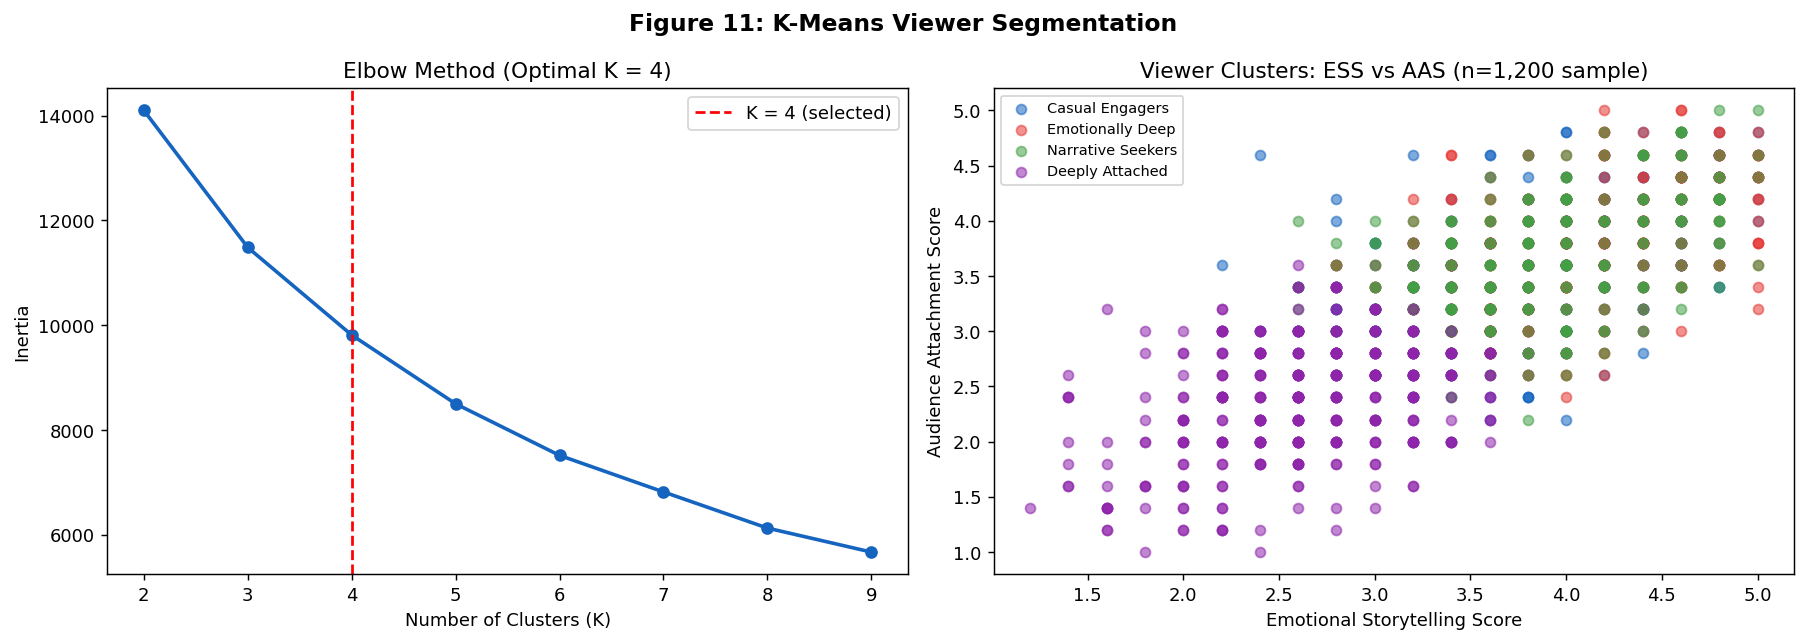

In [43]:
# ─────────────────────────────────────────────────────────────
# FIG 11 – CLUSTERING
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 11: K-Means Viewer Segmentation', fontsize=13, fontweight='bold')

axes[0].plot(range(2, 10), inertia, 'o-', color=COLORS[0], linewidth=2)
axes[0].set_title('Elbow Method (Optimal K = 4)')
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='red', linestyle='--', label='K = 4 (selected)'); axes[0].legend()

samp = df_enc.sample(1200, random_state=42)
for c, (lbl, color) in enumerate(zip(cluster_labels.values(), COLORS[:4])):
    mask = samp['cluster'] == c
    axes[1].scatter(samp.loc[mask, 'Emotional Storytelling Score'],
                    samp.loc[mask, 'Audience Attachment Score'],
                    c=color, label=lbl, alpha=0.55, s=30)
axes[1].set_xlabel('Emotional Storytelling Score')
axes[1].set_ylabel('Audience Attachment Score')
axes[1].set_title('Viewer Clusters: ESS vs AAS (n=1,200 sample)')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
# ─────────────────────────────────────────────────────────────
# STATISTICAL TESTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STATISTICAL TESTS")
print("=" * 65)

high = df_enc[df_enc['high_attachment'] == 1]['Emotional Storytelling Score']
low  = df_enc[df_enc['high_attachment'] == 0]['Emotional Storytelling Score']
t, p = stats.ttest_ind(high, low)
print(f"\n1. T-test (High vs Low Attachment ESS):  t={t:.4f}, p={p:.8f}")
print(f"   High AAS group ESS mean = {high.mean():.3f}")
print(f"   Low  AAS group ESS mean = {low.mean():.3f}")

r, p2 = stats.pearsonr(df['Emotional Storytelling Score'], df['Audience Attachment Score'])
print(f"\n2. Pearson Correlation (ESS vs AAS): r={r:.4f}, p={p2:.8f}")

groups = [df[df['Age'] == g]['Audience Attachment Score'] for g in df['Age'].unique()]
f3, p3 = stats.f_oneway(*groups)
print(f"\n3. ANOVA (AAS across Age Groups): F={f3:.4f}, p={p3:.6f}")
print("   Significant" if p3 < 0.05 else "   Not significant")

female = df_enc[df_enc['Gender'] == 'Female']['Audience Attachment Score']
male   = df_enc[df_enc['Gender'] == 'Male']['Audience Attachment Score']
t5, p5 = stats.ttest_ind(female, male)
print(f"\n4. T-test (Female vs Male AAS): t={t5:.4f}, p={p5:.6f}")
print("   Significant gender difference" if p5 < 0.05 else "   No significant gender difference")

watch_grps = [df[df['How many times watched'] == w2]['Emotional Storytelling Score']
              for w2 in df['How many times watched'].unique()]
f4, p4 = stats.f_oneway(*watch_grps)
print(f"\n5. ANOVA (ESS across Watch Count): F={f4:.4f}, p={p4:.6f}")
print("   Significant" if p4 < 0.05 else "   Not significant")




STATISTICAL TESTS

1. T-test (High vs Low Attachment ESS):  t=52.5422, p=0.00000000
   High AAS group ESS mean = 4.111
   Low  AAS group ESS mean = 3.129

2. Pearson Correlation (ESS vs AAS): r=0.7439, p=0.00000000

3. ANOVA (AAS across Age Groups): F=0.4728, p=0.701251
   Not significant

4. T-test (Female vs Male AAS): t=1.2118, p=0.225636
   No significant gender difference

5. ANOVA (ESS across Watch Count): F=0.1567, p=0.854959
   Not significant
